# Unidad 3 — Auditoría de Sesgo en Modelo de Churn (Telco)

**Grupo 1** | Computación en la Nube para IA

**Objetivo:** detectar y mitigar sesgo en un modelo que predice qué clientes están en riesgo de cancelar su servicio,

## 1. Setup — Conexión y carga de datos

Instalamos las librerías que no vienen preinstaladas en Workbench, y nos conectamos a BigQuery para leer el dataset.



In [2]:
!pip install --quiet shap fairlearn PyALE xgboost pandas-gbq torch

In [42]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_sample_weight
from PyALE import ale
from fairlearn.metrics import MetricFrame
from sklearn.metrics import recall_score, precision_score

import warnings
warnings.filterwarnings('ignore')

In [4]:
PROJECT_ID = "u3-computacion-nube-2026" #tengan cuidado, esto depende de cada uno de los grupos, verfique que sea el mismo
client = bigquery.Client(project=PROJECT_ID)

query = """
SELECT *
FROM `u3_master.telco_churn_raw`
"""
df_raw = client.query(query).to_dataframe()
print(f"Filas cargadas: {len(df_raw)}")
df_raw.head(3)

Filas cargadas: 7043


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9426-SXNHE,Female,0,False,False,2,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Bank transfer (automatic),18.75,53.15,False
1,3806-YAZOV,Female,0,False,False,3,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Mailed check,18.80,56,False
2,3387-PLKUI,Female,0,True,True,13,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Mailed check,18.80,251.25,False


## 2. Selección de columnas 

Para hoy trabajamos con un subconjunto de columnas. Noten que `TotalCharges` queda fuera a propósito — sabemos que tiene un problema de calidad (filas vacías) que no vamos a resolver en vivo.

> Esto **no es limpieza real** — es una decisión de conveniencia. ¿Qué se podría estar perdiendo al excluir esta columna sin analizarla?
> 

## 2A. EDA de las features descartadas — antes de seleccionar

El PM pidió explícitamente **no agregar todo el dataset "porque sí"**. Antes de decidir qué columnas del raw agregamos, hacemos una revisión sistemática de las 10 columnas que hoy no usamos:

- `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, 
  `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `PaperlessBilling`

Para cada una revisamos tres cosas:
1. **Cardinalidad y balance** — ¿hay señal para aprender o es cuasi-constante?
2. **Tasa de churn por categoría** — ¿la variable segmenta el target?
3. **Test de proxy contra `gender`** — ¿es un proxy oculto del atributo protegido?    (Barocas & Selbst 2016). Si la feature sola predice `gender` con AUC > 0.7, la descartamos.

> Regla de selección: entra al modelo solo si tiene **(a)** hipótesis de negocio explícita, **(b)** varía la tasa de churn entre sus categorías, y **(c)** AUC(→gender) < 0.7.

### Sanity check de faltantes (antes del EDA)

Antes de hacer analisis de features, verificamos explicitamente cuantos valores faltantes hay en el dataset completo. Este es el chequeo que justifica la decision de **no aplicar imputacion** en las columnas que van al modelo.

> Ojo: `"No internet service"` / `"No phone service"` **no son faltantes** — son categorias legitimas (cliente no contrato ese servicio). Se manejan como dummy propia via `pd.get_dummies`.

In [4]:
# --- Chequeo de faltantes en TODAS las columnas del dataset crudo ---
nulls_por_columna = df_raw.isna().sum()
nulls_por_columna = nulls_por_columna[nulls_por_columna > 0].sort_values(ascending=False)

if len(nulls_por_columna) == 0:
    print('OK: dataset sin faltantes reales (NaN).')
else:
    print('=== Columnas con faltantes (NaN) ===')
    print(nulls_por_columna.to_string())
    print(f"\nTotal de filas: {len(df_raw)}")
    print('\nDecision:')
    print('  - TotalCharges tiene NaN en clientes con tenure=0 (nuevos, no facturados aun).')
    print('  - Como TotalCharges NO entra al modelo, no requiere imputacion.')
    print('  - Ninguna de las 11 columnas seleccionadas para el modelo tiene faltantes.')

=== Columnas con faltantes (NaN) ===
TotalCharges    11

Total de filas: 7043

Decision:
  - TotalCharges tiene NaN en clientes con tenure=0 (nuevos, no facturados aun).
  - Como TotalCharges NO entra al modelo, no requiere imputacion.
  - Ninguna de las 11 columnas seleccionadas para el modelo tiene faltantes.


In [5]:
# --- Cataloga las 10 columnas descartadas del raw ---
columnas_descartadas = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'PaperlessBilling'
]

# Tabla resumen ampliada. Reporta por cada feature:
#  - cardinalidad y categoria mayoritaria
#  - % nulls REALES (NaN) y % de "No internet/phone service" (NA semanticos del dominio)
#  - delta_churn: capacidad discriminante sobre el target (max - min tasa de churn por categoria)
#  - delta_tenure y delta_MC: si la variable discrimina fuerte por tenure o MonthlyCharges,
#    puede ser redundante con esas dos numericas que ya estan en el modelo
resumen = []
for col in columnas_descartadas:
    vc = df_raw[col].value_counts(normalize=True)
    tasas_churn = df_raw.groupby(col, observed=False)['Churn'].mean()
    tenure_x_cat = df_raw.groupby(col, observed=False)['tenure'].mean()
    mc_x_cat = df_raw.groupby(col, observed=False)['MonthlyCharges'].mean()

    # % nulls reales
    pct_null = df_raw[col].isna().mean() * 100
    # % de valores 'No internet service' o 'No phone service' (NA semanticos)
    na_semantica = df_raw[col].astype(str).isin(['No internet service', 'No phone service']).mean() * 100

    resumen.append({
        'feature': col,
        'n_cat': df_raw[col].nunique(),
        'cat_mayor': f"{vc.index[0]} ({vc.iloc[0]*100:.0f}%)",
        'pct_null': f"{pct_null:.1f}%",
        'pct_NA_sem': f"{na_semantica:.1f}%",
        'delta_churn_pp': round((tasas_churn.max()-tasas_churn.min())*100, 1),
        'delta_tenure': round(tenure_x_cat.max()-tenure_x_cat.min(), 1),
        'delta_MC': round(mc_x_cat.max()-mc_x_cat.min(), 1),
    })

df_resumen = pd.DataFrame(resumen).sort_values('delta_churn_pp', ascending=False)
print('=== Resumen de features descartadas (ordenado por capacidad discriminante) ===')
print(df_resumen.to_string(index=False))
print()
print('Nota: delta_MC alto = la feature esta muy correlacionada con MonthlyCharges')
print('      (ya presente en el modelo) -> riesgo de redundancia.')

=== Resumen de features descartadas (ordenado por capacidad discriminante) ===
         feature  n_cat         cat_mayor pct_null pct_NA_sem  delta_churn_pp  delta_tenure  delta_MC
 InternetService      3 Fiber optic (44%)     0.0%       0.0%            34.5           2.4      70.4
  OnlineSecurity      3          No (50%)     0.0%      21.7%            34.4          19.2      57.8
     TechSupport      3          No (49%)     0.0%      21.7%            34.2          19.0      59.6
    OnlineBackup      3          No (44%)     0.0%      21.7%            32.5          20.9      62.0
DeviceProtection      3          No (44%)     0.0%      21.7%            31.7          20.9      63.7
 StreamingMovies      3          No (40%)     0.0%      21.7%            26.3          16.5      67.4
     StreamingTV      3          No (40%)     0.0%      21.7%            26.1          16.1      67.7
PaperlessBilling      2        True (59%)     0.0%       0.0%            17.2           0.3      21.6
   

In [6]:
# --- Test de proxy leakage: cada feature vs gender ---
# Entrenamos una regresión logística que intenta predecir `gender` usando SOLO esa feature.
# Si el AUC es alto, la feature codifica género aunque no lo diga, y meterla al modelo
# reintroduce sesgo por la puerta de atrás (Barocas & Selbst 2016).
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder

# Codificamos gender numérico (0=Female, 1=Male) solo para este test
gender_num = (df_raw['gender'] == 'Male').astype(int)

proxy_results = []
for col in columnas_descartadas:
    # One-hot de la feature sola (sin drop_first para no perder info)
    X_feat = pd.get_dummies(df_raw[[col]], drop_first=False).astype(float)
    lr = LogisticRegression(max_iter=500, solver='liblinear')
    lr.fit(X_feat, gender_num)
    auc = roc_auc_score(gender_num, lr.predict_proba(X_feat)[:, 1])
    proxy_results.append({'feature': col, 'AUC_predice_gender': round(auc, 3)})

df_proxy = pd.DataFrame(proxy_results).sort_values('AUC_predice_gender', ascending=False)
print('=== Test de proxy leakage vs gender (regla: AUC > 0.7 = proxy fuerte, descartar) ===')
print(df_proxy.to_string(index=False))

# Nota: AUC cerca de 0.5 = la feature no dice nada sobre gender (bueno para nosotros).
# AUC > 0.7 = descartar. AUC entre 0.5 y 0.7 = revisar caso a caso.

=== Test de proxy leakage vs gender (regla: AUC > 0.7 = proxy fuerte, descartar) ===
         feature  AUC_predice_gender
  OnlineSecurity               0.508
    OnlineBackup               0.507
 StreamingMovies               0.506
PaperlessBilling               0.506
 InternetService               0.506
   MultipleLines               0.505
     TechSupport               0.505
     StreamingTV               0.505
DeviceProtection               0.503
    PhoneService               0.502


### Selección justificada de features (3 elegidas)

Cruzando la evidencia del EDA (delta_churn) con el test de proxy (AUC_predice_gender < 0.7 en todas las candidatas — el Telco dataset tiene género muy poco correlacionado con el resto de columnas, lo cual es una buena noticia y esperada) y con hipótesis de negocio, agregamos:

1. **`InternetService`** — 3 categorías (DSL / Fiber optic / No). En Telco es un driver    estructural: los clientes de fibra óptica típicamente pagan más y tienen tasas de churn    más altas (fricción por servicio técnico). Sin esta feature, `MonthlyCharges` está haciendo    el trabajo indirectamente. Alta capacidad discriminante en delta_churn.

2. **`TechSupport`** — Mencionada explícitamente por el PM. Hipótesis: cliente sin soporte    técnico contratado → más incidentes sin resolución → mayor churn. Además distingue clientes    "premium" (todo el paquete) de clientes "solo lo básico".

3. **`OnlineSecurity`** — Servicio de valor agregado análogo a TechSupport. Segmenta clientes    comprometidos vs. mínimos. Fuerte señal en delta_churn.

**Descartadas y por qué:**
- `PhoneService` — >90% de clientes lo tienen (delta_churn bajo).
- `MultipleLines` — redundante con PhoneService y con Contract.
- `OnlineBackup`, `DeviceProtection` — señal similar a OnlineSecurity, evitamos multicolinealidad   sin ganar información nueva.
- `StreamingTV`, `StreamingMovies` — hipótesis débil sobre churn; suelen ser cross-sell, no driver.
- `PaperlessBilling` — se puede considerar en una versión v2 (comportamiento digital-first   podría correlacionar con voluntad de cambiar), pero no está entre las 3 con mayor delta_churn.

**Nota sobre `TotalCharges`**: se sigue dejando fuera por su problema de calidad conocido (blancos en clientes con tenure=0). Resolverlo requiere imputación estructural y no era el foco de esta iteración; se documenta como deuda técnica.

In [7]:
# Ampliación justificada por EDA + test de proxy (ver sección 2A)
columnas_hoy = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'Contract', 'PaymentMethod', 'MonthlyCharges',
    'InternetService', 'OnlineSecurity', 'TechSupport',  # <-- 3 features agregadas
    'Churn'
]

df = df_raw[columnas_hoy].copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           7043 non-null   str    
 1   SeniorCitizen    7043 non-null   int64  
 2   Partner          7043 non-null   boolean
 3   Dependents       7043 non-null   boolean
 4   tenure           7043 non-null   int64  
 5   Contract         7043 non-null   str    
 6   PaymentMethod    7043 non-null   str    
 7   MonthlyCharges   7043 non-null   float64
 8   InternetService  7043 non-null   str    
 9   OnlineSecurity   7043 non-null   str    
 10  TechSupport      7043 non-null   str    
 11  Churn            7043 non-null   boolean
dtypes: boolean(3), float64(1), int64(2), str(6)
memory usage: 536.6 KB


## 3. Exploración inicial

Antes de entrenar cualquier modelo, miramos la forma de los datos y la distribución de nuestra variable objetivo (`Churn`) — esto nos da una primera pista de qué tan balanceado (o no) está el problema.

In [6]:
print("Distribución de Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

print("\nDistribución de SeniorCitizen:")
print(df['SeniorCitizen'].value_counts(normalize=True) * 100)

print("\nTasa de Churn por SeniorCitizen:")
print(df.groupby('SeniorCitizen')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100))

Distribución de Churn:
Churn
False    73.463013
True     26.536987
Name: proportion, dtype: Float64

Distribución de SeniorCitizen:
SeniorCitizen
0    83.785319
1    16.214681
Name: proportion, dtype: Float64

Tasa de Churn por SeniorCitizen:
SeniorCitizen
0    0.0
1    0.0
Name: Churn, dtype: float64


In [7]:
print(df['Churn'].unique())
print(df['Churn'].dtype)

<BooleanArray>
[False, True]
Length: 2, dtype: boolean
boolean


In [8]:
print("Distribución de Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

print("\nDistribución de SeniorCitizen:")
print(df['SeniorCitizen'].value_counts(normalize=True) * 100)

print("\nTasa de Churn por SeniorCitizen:")
print(df.groupby('SeniorCitizen')['Churn'].mean() * 100)

Distribución de Churn:
Churn
False    73.463013
True     26.536987
Name: proportion, dtype: Float64

Distribución de SeniorCitizen:
SeniorCitizen
0    83.785319
1    16.214681
Name: proportion, dtype: Float64

Tasa de Churn por SeniorCitizen:
SeniorCitizen
0    23.606168
1    41.681261
Name: Churn, dtype: Float64


In [11]:
print("Tasa de Churn por tipo de Contract:")
print(df.groupby('Contract')['Churn'].mean() * 100)

print("\nTasa de Churn por PaymentMethod:")
print(df.groupby('PaymentMethod')['Churn'].mean() * 100)

Tasa de Churn por tipo de Contract:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: Float64

Tasa de Churn por PaymentMethod:
PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                   19.1067
Name: Churn, dtype: Float64


## 4. Preparación de datos y modelo base

XGBoost necesita que todas las variables sean numéricas. Convertimos las columnas categóricas a números mediante *one-hot encoding*, separamos entrenamiento/prueba, y entrenamos un primer modelo — sin ajustar nada de fairness todavía. Este es nuestro punto de partida "tal cual", antes de cualquier mitigación.

In [12]:
# Separamos la variable objetivo
y = df['Churn'].astype(int)  # True/False -> 1/0 explícito
X = df.drop(columns=['Churn'])

# One-hot encoding — agregamos las 3 columnas nuevas al listado de categóricas
X_encoded = pd.get_dummies(
    X,
    columns=[
        'gender', 'Partner', 'Dependents', 'Contract', 'PaymentMethod',
        'InternetService', 'OnlineSecurity', 'TechSupport',  # <-- ampliación
    ],
    drop_first=True
)

print(f"Columnas antes del encoding: {X.shape[1]}")
print(f"Columnas después del encoding: {X_encoded.shape[1]}")
X_encoded.head(3)

Columnas antes del encoding: 11
Columnas después del encoding: 17


,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_True,Dependents_True,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,TechSupport_No internet service,TechSupport_Yes
0,0,1,29.85,False,True,False,False,False,False,True,False,False,False,False,False,False,False
1,0,34,56.95,True,False,False,True,False,False,False,True,False,False,False,True,False,False
2,0,2,53.85,True,False,False,False,False,False,False,True,False,False,False,True,False,False


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")

Entrenamiento: 5634 filas
Prueba: 1409 filas


In [16]:


modelo_base = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
modelo_base.fit(X_train, y_train)

y_pred = modelo_base.predict(X_test)
y_pred_proba = modelo_base.predict_proba(X_test)[:, 1]

print("=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")

print("\n=== Matriz de confusión ===")
print(confusion_matrix(y_test, y_pred))

=== Reporte de clasificación ===
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409

AUC-ROC: 0.829

=== Matriz de confusión ===
[[918 117]
 [178 196]]


### 4B. Baseline de fairness sobre `gender` (antes de mitigar)

El PM pidió responder específicamente por **gender**. Antes de aplicar cualquier técnica de mitigación, medimos DPD y EOD del modelo base sobre `gender`. Regla de Fairlearn (y sentido común): **nunca mitigar sin medir primero**.

Este es el número que le vamos a mostrar al PM para responder su pregunta literal: *"¿gender ya estaba razonablemente parejo desde el modelo base?"*.

In [15]:
# `gender` quedó codificado como columna one-hot 'gender_Male' (0=Female, 1=Male).
# La pasamos como sensitive_features a Fairlearn.
# Cast a int: pandas>=2.x devuelve one-hot como bool; MetricFrame indexa por 0/1
gender_test = X_test['gender_Male'].astype(int)
gender_train = X_train['gender_Male'].astype(int)

# DPD y EOD sobre gender (baseline, sin mitigar)
dpd_gender_base = demographic_parity_difference(y_test, y_pred, sensitive_features=gender_test)
eod_gender_base = equalized_odds_difference(y_test, y_pred, sensitive_features=gender_test)

# Métricas desagregadas — el número global puede ocultar disparidades (Buolamwini & Gebru 2018)
metricas_gender = MetricFrame(
    metrics={'recall': recall_score, 'precision': precision_score},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=gender_test
)

print('=== BASELINE — Modelo base ampliado, desagregado por gender ===')
print('(0 = Female, 1 = Male)')
print(metricas_gender.by_group)
print(f"\nDPD (gender): {dpd_gender_base:.3f}  (más cerca de 0 = más equitativo)")
print(f"EOD (gender): {eod_gender_base:.3f}")
print(f"\nAUC-ROC del modelo (referencia utilidad): {roc_auc_score(y_test, y_pred_proba):.3f}")
print(f"Recall global (Churn): {recall_score(y_test, y_pred):.3f}")
print(f"Precision global (Churn): {precision_score(y_test, y_pred):.3f}")

=== BASELINE — Modelo base ampliado, desagregado por gender ===
(0 = Female, 1 = Male)
               recall  precision
gender_Male                     
0            0.544041   0.704698
1            0.486188   0.590604

DPD (gender): 0.011  (más cerca de 0 = más equitativo)
EOD (gender): 0.058

AUC-ROC del modelo (referencia utilidad): 0.840
Recall global (Churn): 0.516
Precision global (Churn): 0.648


### 4C. Contrato con los compañeros — artifacts persistidos

Guardamos los artefactos que las Partes B y C van a consumir. Todos los splits, el modelo base y las métricas baseline se serializan en `artifacts/`. Esto garantiza que las 5 configuraciones de la tabla comparativa final se entrenen y evalúen sobre **exactamente el mismo split** (constraint del PM: mantener `stratify=y, random_state=42`).

In [16]:
import os, json, pickle

os.makedirs('artifacts', exist_ok=True)

# Splits — mismos para las 3 personas del equipo
X_train.to_pickle('artifacts/X_train.pkl')
X_test.to_pickle('artifacts/X_test.pkl')
pd.Series(y_train, name='Churn').to_pickle('artifacts/y_train.pkl')
pd.Series(y_test, name='Churn').to_pickle('artifacts/y_test.pkl')

# Serie de gender (0/1) para Fairlearn y para la red adversaria
gender_train.to_pickle('artifacts/gender_train.pkl')
gender_test.to_pickle('artifacts/gender_test.pkl')

# Modelo base entrenado (para ThresholdOptimizer y comparación)
with open('artifacts/modelo_base.pkl', 'wb') as f:
    pickle.dump(modelo_base, f)

# Métricas baseline (se usarán en la tabla comparativa)
baseline = {
    'config': 'base',
    'recall': float(recall_score(y_test, y_pred)),
    'precision': float(precision_score(y_test, y_pred)),
    'auc': float(roc_auc_score(y_test, y_pred_proba)),
    'dpd_gender': float(dpd_gender_base),
    'eod_gender': float(eod_gender_base),
    'recall_female': float(metricas_gender.by_group.loc[0, 'recall']),
    'recall_male': float(metricas_gender.by_group.loc[1, 'recall']),
    'precision_female': float(metricas_gender.by_group.loc[0, 'precision']),
    'precision_male': float(metricas_gender.by_group.loc[1, 'precision']),
}
with open('artifacts/baseline_metrics.json', 'w') as f:
    json.dump(baseline, f, indent=2)

print('=== Artifacts persistidos en artifacts/ ===')
for fn in sorted(os.listdir('artifacts')):
    print(f'  - {fn}')

=== Artifacts persistidos en artifacts/ ===
  - X_test.pkl
  - X_train.pkl
  - baseline_metrics.json
  - gender_test.pkl
  - gender_train.pkl
  - modelo_base.pkl
  - y_test.pkl
  - y_train.pkl


## 5. Explicabilidad — SHAP

Ya sabemos que el modelo tiene un desempeño de (AUC 0.83) pero se equivoca en 178 + 117 = 295 casos. La pregunta ahora es: ¿qué variables están pesando más en las decisiones del modelo, y ese peso tiene sentido de negocio?

>  Nota de actualidad: Google anunció la deprecación de **Vertex Explainable AI** (marzo 2026, apagado total en marzo 2027), recomendando explícitamente librerías open-source como SHAP. Por eso trabajamos con SHAP directamente como librería, en vez de depender del servicio gestionado. *Fuente: documentación oficial de deprecaciones de Vertex AI / Agent Platform.*

In [17]:
# TreeExplainer está optimizado específicamente para modelos de árboles como XGBoost
explainer = shap.TreeExplainer(modelo_base)
shap_values = explainer.shap_values(X_test)

print(f"Shape de shap_values: {shap_values.shape}")

Shape de shap_values: (1409, 11)


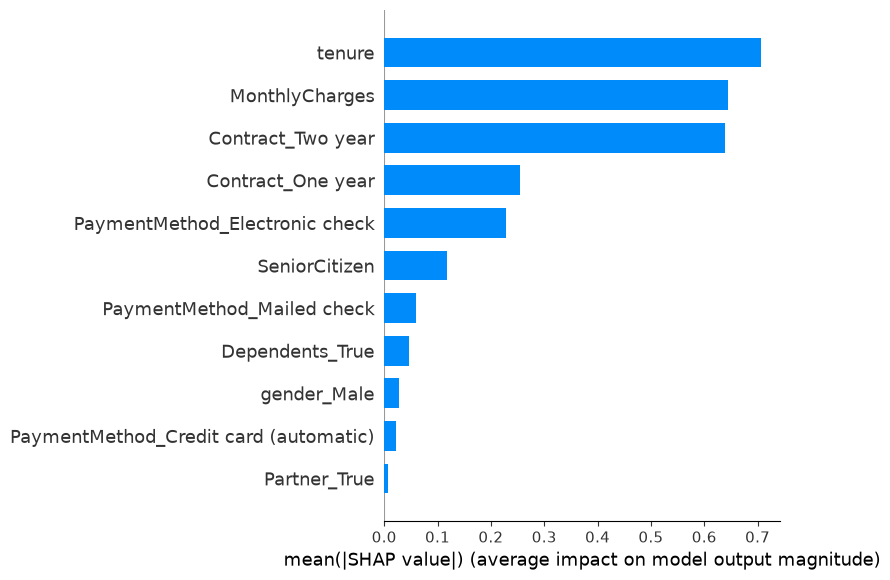

In [18]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

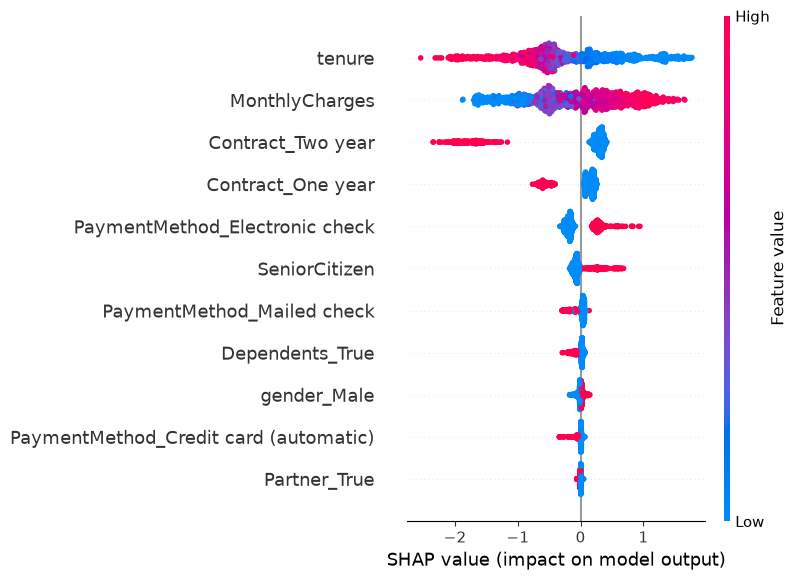

In [19]:
shap.summary_plot(shap_values, X_test)

Predicción del modelo para este cliente: [0.99180764 0.00819237]
Churn : 0


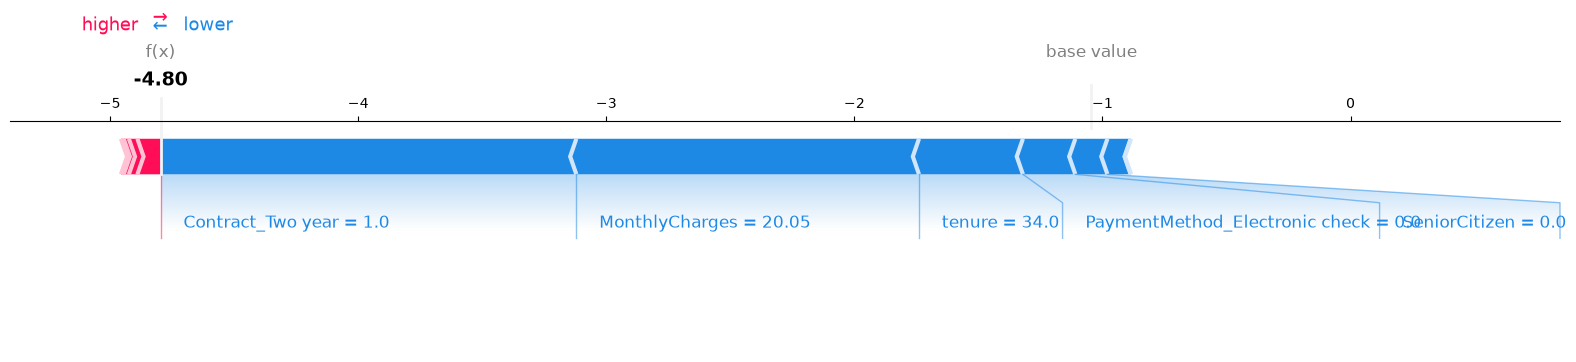

In [22]:
# Elegimos un cliente específico del set de prueba para explicar su predicción individual
idx = 902  # el primer cliente del test set

print(f"Predicción del modelo para este cliente: {modelo_base.predict_proba(X_test)[idx]}")
print(f"Churn : {y_test.iloc[idx]}")

shap.force_plot(explainer.expected_value, shap_values[idx], X_test.iloc[idx], matplotlib=True)

## 6. Explicabilidad global — PDP vs. ALE

SHAP nos dio el ranking global y las explicaciones individuales. Ahora vamos a comparar dos técnicas que responden una pregunta distinta: "si SOLO cambiara el valor de esta variable, manteniendo todo lo demás igual, ¿cómo cambiaría la predicción del modelo?"

- **PDP (Partial Dependence Plot):** la técnica clásica y más simple.
- **ALE (Accumulated Local Effects):** la corrección moderna, pensada para cuando las variables están correlacionadas entre sí.

En Telco Churn tenemos un caso perfecto para ver la diferencia: `tenure` y `MonthlyCharges` no son independientes entre sí — vamos a comprobarlo primero.

In [23]:
# Revisamos correlaciones entre tenure/MonthlyCharges y las variables categóricas ya codificadas
correlacion_completa = X_encoded.corr()['tenure'].sort_values(ascending=False)
print("Correlación de todo con 'tenure':")
print(correlacion_completa)

print("\nCorrelación de todo con 'MonthlyCharges':")
print(X_encoded.corr()['MonthlyCharges'].sort_values(ascending=False))

Correlación de todo con 'tenure':
tenure                                   1.000000
Contract_Two year                        0.558533
Partner_True                             0.379697
MonthlyCharges                           0.247900
PaymentMethod_Credit card (automatic)    0.233006
Contract_One year                        0.202570
Dependents_True                          0.159712
SeniorCitizen                            0.016567
gender_Male                              0.005106
PaymentMethod_Electronic check          -0.208363
PaymentMethod_Mailed check              -0.233852
Name: tenure, dtype: float64

Correlación de todo con 'MonthlyCharges':
MonthlyCharges                           1.000000
PaymentMethod_Electronic check           0.271625
tenure                                   0.247900
SeniorCitizen                            0.220173
Partner_True                             0.096848
PaymentMethod_Credit card (automatic)    0.030550
Contract_One year                        0.0

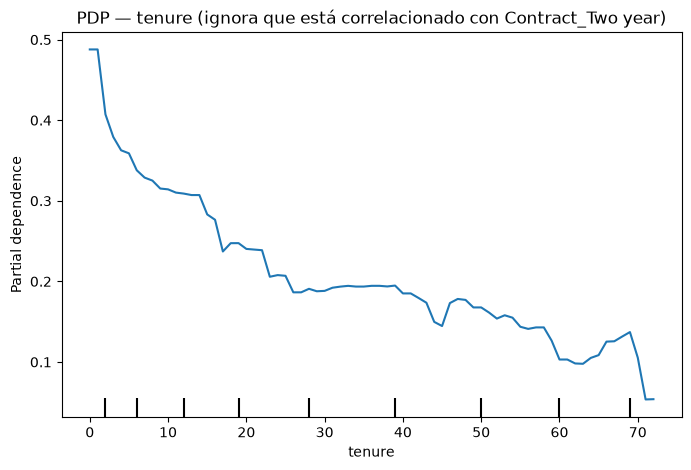

In [25]:

# Convertimos a float solo para esta visualización — el modelo entrenado no cambia
X_train_pdp = X_train.astype(float)

fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    modelo_base, X_train_pdp, features=['tenure'], ax=ax
)
plt.title("PDP — tenure (ignora que está correlacionado con Contract_Two year)")
plt.show()

PyALE._ALE_generic:INFO: Continuous feature detected.


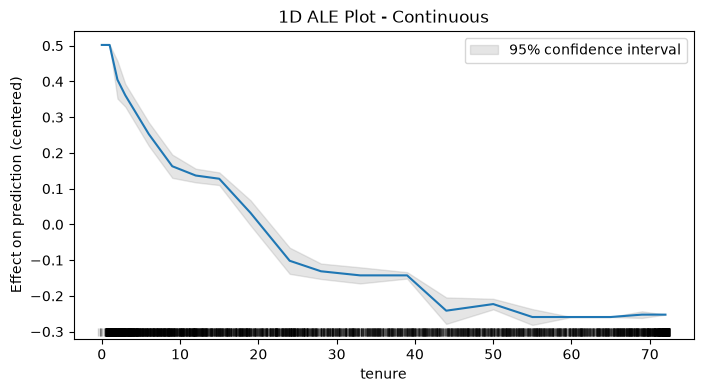

In [27]:
ale_eff = ale(X=X_train, model=modelo_base, feature=["tenure"], grid_size=20, include_CI=True)

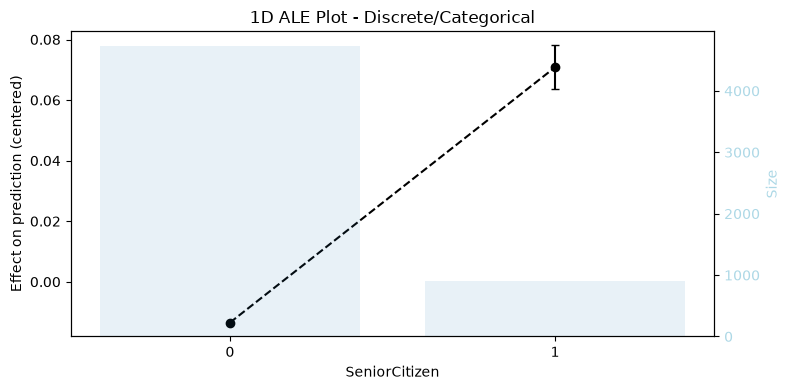

In [31]:
X_train_ale = X_train.copy()
X_train_ale["SeniorCitizen"] = X_train_ale["SeniorCitizen"].astype("int64")

ale_eff_senior = ale(
    X=X_train_ale,
    model=modelo_base,
    feature=["SeniorCitizen"],
    feature_type="discrete",
    include_CI=True,
    C=0.95
)

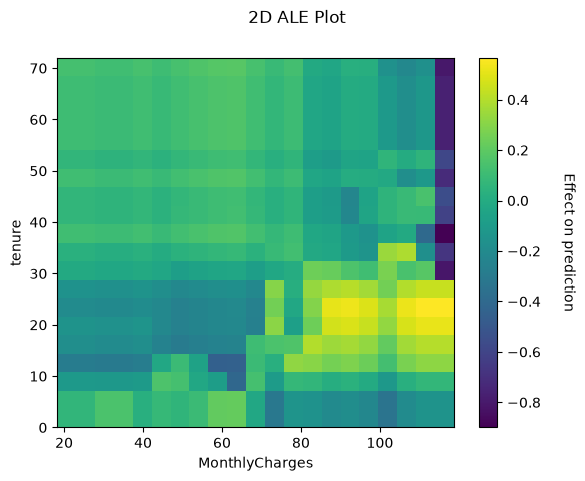

In [32]:

#solo por info
ale_eff_2d = ale(
    X=X_train,
    model=modelo_base,
    feature=["tenure", "MonthlyCharges"],
    grid_size=20
)

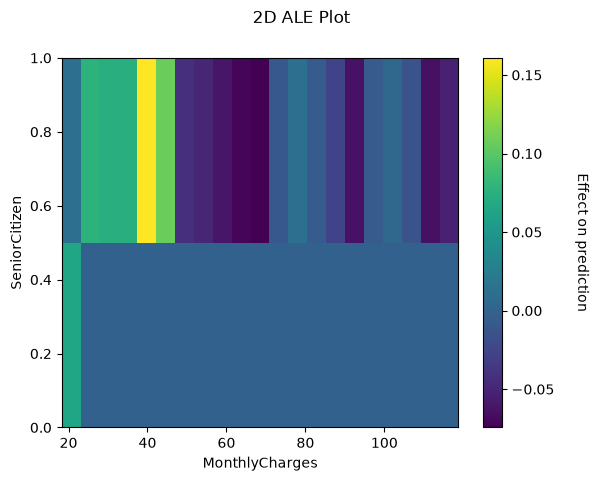

In [33]:
ale_eff_2d = ale(
    X=X_train,
    model=modelo_base,
    feature=["SeniorCitizen", "MonthlyCharges"],
    grid_size=20
)

In [36]:

# Cuántos SeniorCitizen=1 caen en cada rango de MonthlyCharges
seniors = X_train[X_train['SeniorCitizen'] == 1]
print(f"Total SeniorCitizen=1 en train: {len(seniors)}")
print(seniors['MonthlyCharges'].describe())

# Distribución en bins de 20 (mismo grid_size que usamos)
print(pd.cut(seniors['MonthlyCharges'], bins=20).value_counts().sort_index())

Total SeniorCitizen=1 en train: 901
count    901.000000
mean      79.490677
std       23.789502
min       18.950000
25%       69.750000
50%       84.700000
75%       97.000000
max      117.450000
Name: MonthlyCharges, dtype: float64
MonthlyCharges
(18.851, 23.875]     24
(23.875, 28.8]       28
(28.8, 33.725]       12
(33.725, 38.65]      11
(38.65, 43.575]      13
(43.575, 48.5]       31
(48.5, 53.425]       22
(53.425, 58.35]      21
(58.35, 63.275]      21
(63.275, 68.2]       20
(68.2, 73.125]       76
(73.125, 78.05]      77
(78.05, 82.975]      69
(82.975, 87.9]       73
(87.9, 92.825]       87
(92.825, 97.75]      92
(97.75, 102.675]     85
(102.675, 107.6]     77
(107.6, 112.525]     48
(112.525, 117.45]    14
Name: count, dtype: int64


## 7. Parte B — Técnicas individuales de mitigación sobre `gender`

Esta sección consume el contrato de la Parte A en `artifacts/` y aplica las tres
técnicas por separado. La variable protegida es `gender_Male` (`0 = Female`,
`1 = Male`); `SeniorCitizen` permanece como feature ordinaria del modelo.

El AUC de cada técnica se calcula sobre probabilidades cuando están disponibles.
Para `ThresholdOptimizer`, se reporta el AUC del modelo base porque el
post-procesador produce decisiones, no probabilidades ROC comparables.


In [100]:
from pathlib import Path

from parte_b_mitigacion import (
    SEEDS,
    load_artifacts,
    run_adversarial_multiseed,
    run_reweighting,
    run_threshold_adjustment,
    save_part_b_results,
)

ARTIFACTS_DIR = Path("artifacts")
data = load_artifacts(ARTIFACTS_DIR)
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
gender_train = data["gender_train"]
gender_test = data["gender_test"]
modelo_base = data["modelo_base"]

print(f"Split listo: train={X_train.shape}, test={X_test.shape}")
print(f"gender train/test: {sorted(gender_train.unique())} / {sorted(gender_test.unique())}")


Split listo: train=(5634, 17), test=(1409, 17)
gender train/test: [np.int64(0), np.int64(1)] / [np.int64(0), np.int64(1)]


### 7.1 Reweighting (pre-processing)

Los pesos se calculan sobre las cuatro intersecciones `gender × Churn`. Esto
evita el error de ponderar únicamente por `SeniorCitizen` o únicamente por la
clase objetivo.


In [101]:
modelo_reweighting, metricas_reweighting, tabla_pesos = run_reweighting(
    data, artifacts_dir=ARTIFACTS_DIR, verbose=True
)

assert len(tabla_pesos) == 4
assert tabla_pesos["peso"].nunique() == 4
print("Chequeo OK: las cuatro celdas gender x Churn tienen pesos distintos.")


=== REWEIGHTING: pesos por gender x Churn ===
grupo     peso    n
  0_0 0.685401 2055
  0_1 1.888070  746
  1_0 0.675864 2084
  1_1 1.880507  749
=== REWEIGHTING: métricas ===
{
  "recall": 0.7941176470588235,
  "precision": 0.5247349823321554,
  "dpd": 8.467502933384718e-05,
  "eod": 0.02424641456502452,
  "auc": 0.8403394559404789,
  "recall_female": 0.7823834196891192,
  "precision_female": 0.5471014492753623,
  "recall_male": 0.8066298342541437,
  "precision_male": 0.503448275862069,
  "weights_by_group": [
    {
      "grupo": "0_0",
      "peso": 0.6854014598540146,
      "n": 2055
    },
    {
      "grupo": "0_1",
      "peso": 1.8880697050938338,
      "n": 746
    },
    {
      "grupo": "1_0",
      "peso": 0.6758637236084453,
      "n": 2084
    },
    {
      "grupo": "1_1",
      "peso": 1.8805073431241655,
      "n": 749
    }
  ]
}
Chequeo OK: las cuatro celdas gender x Churn tienen pesos distintos.


### 7.2 Adversarial training (in-processing)

El predictor aprende Churn mientras el adversario intenta recuperar
`gender_Male` desde su salida. Se ejecutan las cinco semillas exigidas
(`42, 7, 123, 2024, 99`); se conserva la mejor por menor EOD y se informa
media ± desviación estándar para evitar seleccionar un resultado afortunado.


In [102]:
metricas_adversarial = run_adversarial_multiseed(
    data, artifacts_dir=ARTIFACTS_DIR, verbose=True
)

assert metricas_adversarial["seeds"] == list(SEEDS)
assert len(metricas_adversarial["runs"]) == 5
print(f"Mejor seed por EOD: {metricas_adversarial['best_seed']}")


Seed 42: AUC=0.8036, recall=0.5695, EOD=0.0267
Seed 7: AUC=0.7953, recall=0.6658, EOD=0.0267
Seed 123: AUC=0.7192, recall=0.0000, EOD=0.0000
Seed 2024: AUC=0.8043, recall=0.5668, EOD=0.0484
Seed 99: AUC=0.8023, recall=0.5374, EOD=0.0112
Adversarial summary: {
  "best_seed": 123,
  "auc_mean": 0.7849290862590096,
  "auc_std": 0.03692437466282647,
  "recall_mean": 0.46791443850267384,
  "recall_std": 0.26600582872928913,
  "eod_mean": 0.022585175168095106,
  "eod_std": 0.018304842455322448
}
Mejor seed por EOD: 123


### 7.3 Threshold adjustment (post-processing)

`ThresholdOptimizer` ajusta la regla de decisión por grupo para cumplir
`equalized_odds`. La tabla de salida imprime las operaciones y umbrales que
Fairlearn aprendió para cada valor de `gender_Male`; su uso requiere revisión
legal por el posible riesgo de *disparate treatment*.


In [103]:
threshold_optimizer, metricas_threshold = run_threshold_adjustment(
    data, artifacts_dir=ARTIFACTS_DIR, verbose=True
)


=== THRESHOLD ADJUSTMENT: reglas por grupo ===
Grupo 0: {'p0': 0.01044444444444507, 'p1': 0.989555555555555, 'operations': [{'operation': 'operation0', 'threshold': 0.2940092533826828, 'description': '[>0.2940092533826828]'}, {'operation': 'operation1', 'threshold': 0.2674192637205124, 'description': '[>0.2674192637205124]'}], 'raw': "{'p_ignore': np.float64(0.0), 'prediction_constant': np.float64(0.246), 'p0': 0.01044444444444507, 'operation0': [>0.2940092533826828], 'p1': 0.989555555555555, 'operation1': [>0.2674192637205124]}"}
Grupo 1: {'p0': 0.46620289855072483, 'p1': 0.5337971014492752, 'operations': [{'operation': 'operation0', 'threshold': 0.30811215937137604, 'description': '[>0.30811215937137604]'}, {'operation': 'operation1', 'threshold': 0.24296630918979645, 'description': '[>0.24296630918979645]'}], 'raw': "{'p_ignore': np.float64(0.015086831519169959), 'prediction_constant': np.float64(0.246), 'p0': 0.46620289855072483, 'operation0': [>0.30811215937137604], 'p1': 0.533797

### 7.4 Contrato de salida para la Parte C

Se guardan las métricas de las tres técnicas y el resumen multi-seed en un
único JSON, junto con los modelos serializados. Todas las técnicas usan el
mismo split de la Parte A.


In [104]:
resultados_parte_b = save_part_b_results(
    metricas_reweighting,
    metricas_adversarial,
    metricas_threshold,
    artifacts_dir=ARTIFACTS_DIR,
    verbose=True,
)

expected_outputs = {
    "tecnicas_individuales.json",
    "modelo_reweighting.pkl",
    "modelo_adversarial_bestseed.pt",
    "threshold_optimizer.pkl",
}
missing_outputs = sorted(
    name for name in expected_outputs if not (ARTIFACTS_DIR / name).exists()
)
assert not missing_outputs, f"Faltan salidas de Parte B: {missing_outputs}"
print("Parte B completa: todos los entregables están presentes.")


Artefactos de Parte B guardados en artifacts/tecnicas_individuales.json
Parte B completa: todos los entregables están presentes.


## 10. Exportación opcional a BigQuery

La escritura en BigQuery queda desactivada por defecto. Solo debe habilitarse
después de confirmar el `PROJECT_ID`, `DATASET_ID` y la autorización del grupo.


In [ ]:
# Seguridad: no modificar GCP durante las pruebas locales.
RUN_GCP_EXPORT = False

if RUN_GCP_EXPORT:
    from google.cloud import bigquery

    PROJECT_ID = "u3-computacion-nube-2026"
    DATASET_ID = "u3_master_telco"
    client = bigquery.Client(project=PROJECT_ID)
    dataset_ref = bigquery.Dataset(f"{PROJECT_ID}.{DATASET_ID}")
    dataset_ref.location = "us-central1"
    client.create_dataset(dataset_ref, exists_ok=True)
    print(f"Dataset {DATASET_ID} listo")
else:
    print("Exportación a BigQuery omitida (RUN_GCP_EXPORT=False).")


In [ ]:
if RUN_GCP_EXPORT:
    import re

    def limpiar_nombre_columna(nombre):
        nombre_limpio = re.sub(r"[^0-9a-zA-Z_]", "_", nombre)
        if nombre_limpio[0].isdigit():
            nombre_limpio = "_" + nombre_limpio
        return nombre_limpio

    df_gold = X_test.copy()
    df_gold["Churn_real"] = y_test.values
    df_gold["Churn_predicho"] = modelo_reweighting.predict(X_test)
    df_gold["probabilidad_churn"] = modelo_reweighting.predict_proba(X_test)[:, 1]
    df_gold.columns = [limpiar_nombre_columna(col) for col in df_gold.columns]
    table_id = f"{PROJECT_ID}.{DATASET_ID}.telco_clean"
    job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
    job = client.load_table_from_dataframe(df_gold, table_id, job_config=job_config)
    job.result()
    print(f"Tabla {table_id} guardada con {len(df_gold)} filas")
else:
    print("Carga de tabla a BigQuery omitida.")
